In [1]:
!pip install ultralytics


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Import Libraries

In [2]:
from pathlib import Path
import random, shutil
import matplotlib.pyplot as plt
import torch, yaml
from ultralytics import YOLO

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


### Extract or Load Dataset

In [3]:
from pathlib import Path
import shutil

ZIP_FILE = "Furniture.v1-furnitureobjects.yolov8" 
DATASET = Path("Furniture.v1-furnitureobjects.yolov8") 


if not DATASET.exists(): 
    shutil.unpack_archive(ZIP_FILE, ".") 
    print("Dataset folder:", DATASET.resolve())


### Inspect the Classes and Dataset

In [4]:
print("Classes: Chair, Sofa, Table")
for split in ["train", "valid", "test"]:
    images = len(list((DATASET / split / "images").glob("*.jpg")))
    labels = len(list((DATASET / split / "labels").glob("*.txt")))
    print(split, "images:", images, "labels:", labels)

Classes: Chair, Sofa, Table
train images: 435 labels: 435
valid images: 109 labels: 109
test images: 146 labels: 146


In [5]:
random.seed(42)

# 1. Fixed variables: Defined paths explicitly instead of using a combined tuple
train_img, train_lbl = DATASET/"train"/"images", DATASET/"train"/"labels"
valid_img, valid_lbl = DATASET/"valid"/"images", DATASET/"valid"/"labels"

valid_img.mkdir(parents=True, exist_ok=True)
valid_lbl.mkdir(parents=True, exist_ok=True)

if not list(valid_img.glob("*.jpg")):
    all_images = list(train_img.glob("*.jpg"))
    chosen = random.sample(all_images, round(len(all_images) * 0.20))
    
    for image in chosen:
        # Move the image
        shutil.move(str(image), str(valid_img))
        
        # 2. Fixed path logic: Look for the label inside the train_lbl folder
        corresponding_label = train_lbl / f"{image.stem}.txt"
        
        # Only move the label file if it actually exists
        if corresponding_label.exists():
            shutil.move(str(corresponding_label), str(valid_lbl / corresponding_label.name))

DATA_YAML = Path("furniture_data.yaml")

# 3. Fixed YAML configuration: Changed "Path" to lowercase "path" for YOLOv8
config = {
    "path": str(DATASET.resolve()), 
    "train": "train/images", 
    "val": "valid/images", 
    "names": {0: "Chair", 1: "Sofa", 2: "Table"}
}

DATA_YAML.write_text(yaml.safe_dump(config, sort_keys=False))

print("Train images:", len(list(train_img.glob("*.jpg"))))
print("Train labels:", len(list(train_lbl.glob("*.txt"))))
print("Valid images:", len(list(valid_img.glob("*.jpg"))))
print(DATA_YAML.read_text())




Train images: 435
Train labels: 435
Valid images: 109
path: C:\Users\Jitendra Dewangan\Desktop\Furniture.v1-furnitureobjects.yolov8
train: train/images
val: valid/images
names:
  0: Chair
  1: Sofa
  2: Table



### Load the small pretrained YOLOv8n model

In [17]:
model = YOLO("yolov8n.pt")
print("Model detected")

100%|██████████| 6.25M/6.25M [00:03<00:00, 1.75MB/s]


Model detected


In [19]:
model.train(
    data=str(DATA_YAML),
    epochs = 2,
    imgsz = 640,
    batch = 8,
    device = DEVICE,
    patience = 5,
    project = "runs",
    name = "furniture",
    exist_ok = True
            )

New https://pypi.org/project/ultralytics/8.4.118 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.168  Python-3.13.2 torch-2.7.1+cpu CPU (Intel Core(TM) i5-8300H 2.30GHz)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=furniture_data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=2, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=furniture, nbs=64, nms=False, opset=None, optimize=False, o

100%|██████████| 755k/755k [00:00<00:00, 1.33MB/s]

Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

 21                  -1  1    493056  ultralytics.nn.modules.block.C2f             [384, 256, 1]                 
 22        [15, 18, 21]  1    751897  ultralytics.nn.modules.head.Detect           [3, [64, 128, 256]]           
Model summary: 129 layers, 3,011,433 parameters, 3,011,417 gradients, 8.2 GFLOPs

Transferred 319/355 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
train: Fast image access  (ping: 0.30.1 ms, read: 97.432.1 MB/s, size: 88.6 KB)


train: Scanning C:\Users\Jitendra Dewangan\Desktop\Furniture.v1-furnitureobjects.yolov8\train\labels... 435 images, 0 backgrounds, 0 corrupt: 100%|██████████| 435/435 [00:00<00:00, 1122.71it/s]


...

                   all        109        109      0.853      0.874      0.938       0.75



2 epochs completed in 0.114 hours.
Optimizer stripped from runs\furniture\weights\last.pt, 6.2MB
Optimizer stripped from runs\furniture\weights\best.pt, 6.2MB

Validating runs\furniture\weights\best.pt...
Ultralytics 8.3.168  Python-3.13.2 torch-2.7.1+cpu CPU (Intel Core(TM) i5-8300H 2.30GHz)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:22<00:00,  3.27s/it]


                   all        109        109      0.869      0.851      0.938      0.751
                 Chair         46         46      0.947      0.848      0.962      0.853
                  Sofa         35         35          1      0.885      0.989       0.77
                 Table         28         28       0.66      0.821      0.862      0.631
Speed: 2.3ms preprocess, 146.1ms inference, 0.0ms loss, 37.1ms postprocess per image
Results saved to runs\furniture


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000019B2C433890>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

### Load the best model and evaluate it

In [6]:
from pathlib import Path
from ultralytics import YOLO

best_files = list(Path(".").rglob("best.pt"))

if len(best_files) == 0:
    print("best.pt was not found.")
    print("Run the training cell completely before running this cell.")

else:
    BEST_PATH = best_files[-1]

    print("Loading model from:")
    print(BEST_PATH.resolve())

    best_model = YOLO(str(BEST_PATH))

    metrics = best_model.val(
        data=str(DATA_YAML),
        device=DEVICE,
    
    )

    print(f"Precision: {metrics.box.mp:.3f}")
    print(f"Recall: {metrics.box.mr:.3f}")
    print(f"mAP50: {metrics.box.map50:.3f}")
    print(f"mAP50-95: {metrics.box.map:.3f}")

Loading model from:
C:\Users\Jitendra Dewangan\Desktop\runs\furniture\weights\best.pt
Ultralytics 8.3.168  Python-3.13.2 torch-2.7.1+cpu CPU (Intel Core(TM) i5-8300H 2.30GHz)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 80.925.6 MB/s, size: 72.2 KB)


val: Scanning C:\Users\Jitendra Dewangan\Desktop\Furniture.v1-furnitureobjects.yolov8\valid\labels.cache... 109 images, 0 backgrounds, 0 corrupt: 100%|██████████| 109/109 [00:00<?, ?it/s]
C:\Users\Jitendra Dewangan\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:17<00:00,  2.46s/it]


                   all        109        109      0.869      0.851      0.938      0.751
                 Chair         46         46      0.947      0.848      0.962      0.853
                  Sofa         35         35          1      0.885      0.989       0.77
                 Table         28         28       0.66      0.821      0.862      0.631
Speed: 2.0ms preprocess, 100.5ms inference, 0.0ms loss, 32.1ms postprocess per image
Results saved to runs\detect\val
Precision: 0.869
Recall: 0.851
mAP50: 0.938
mAP50-95: 0.751


### Predict furniture in unseen test images

In [23]:
test_images = list((DATASET/"test"/"images").glob("*.jpg"))
samples = random.sample(test_images, min(4, len(test_images)))

results = best_model.predict(
    source=[str(x) for x in samples],
    conf=0.2,
    imgsz=640,
    save=True
)


0: 640x640 (no detections), 110.4ms
1: 640x640 (no detections), 110.4ms
2: 640x640 1 Table, 110.4ms
3: 640x640 1 Chair, 110.4ms
Speed: 5.7ms preprocess, 110.4ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs\detect\predict


### Display predictions

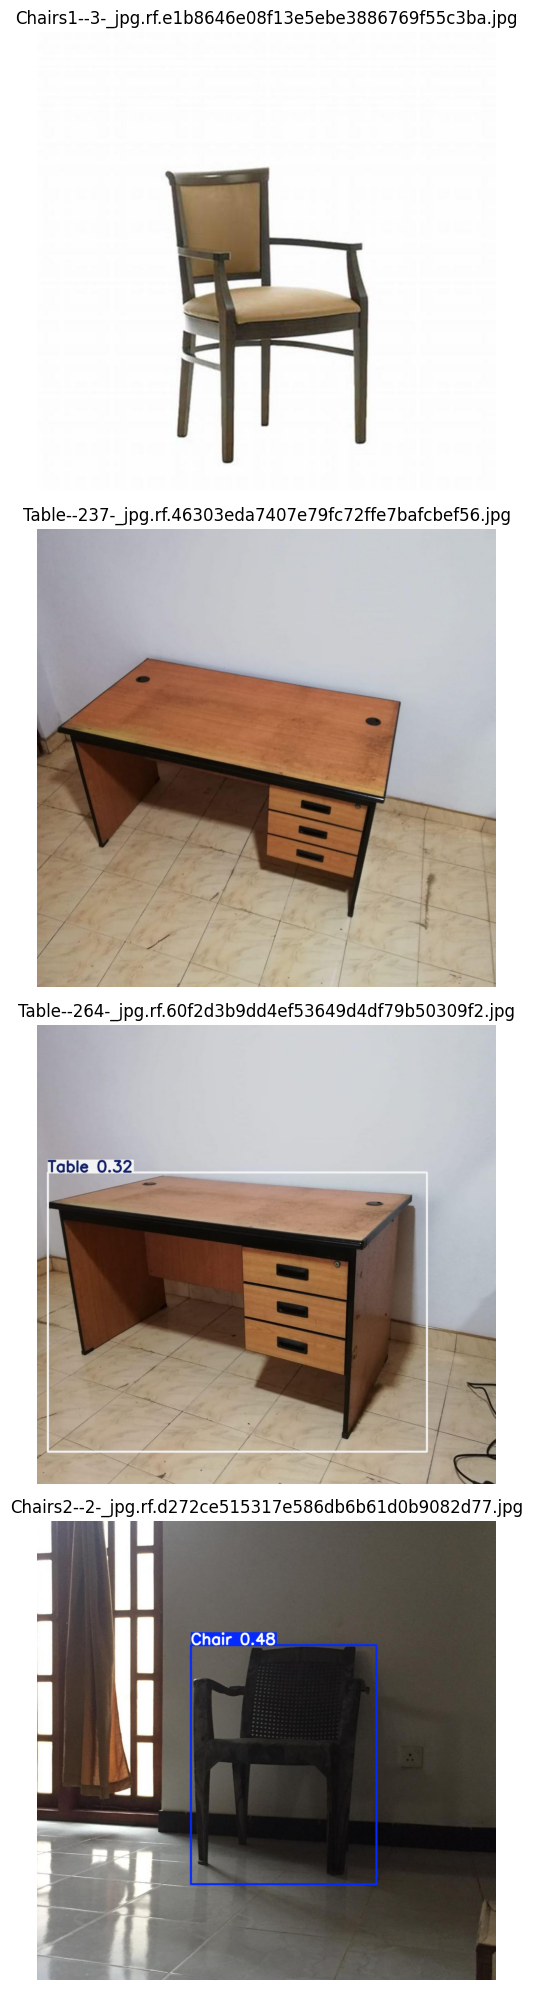

In [25]:
%matplotlib inline
plt.figure(figsize=(12, 5 * len(results)))

for i, result in enumerate(results, 1):
    image = result.plot()[..., ::-1]
    plt.subplot(len(results), 1, i)
    plt.imshow(image)
    plt.title(Path(result.path).name)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Save the trained model with a clear name

In [26]:
FINAL_MODEL = Path("furniture_yolov8n_best.pt")
shutil.copy2(BEST_PATH, FINAL_MODEL)
print("Saved model:", FINAL_MODEL.resolve())

Saved model: C:\Users\Jitendra Dewangan\Desktop\furniture_yolov8n_best.pt
